<a href="https://colab.research.google.com/github/pranitasirsat152-creator/ford_car_dashboard/blob/main/App.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

import os
print(os.listdir())

Saving ford.csv to ford.csv
['.config', 'ford.csv', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import joblib

In [4]:
df = pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [7]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


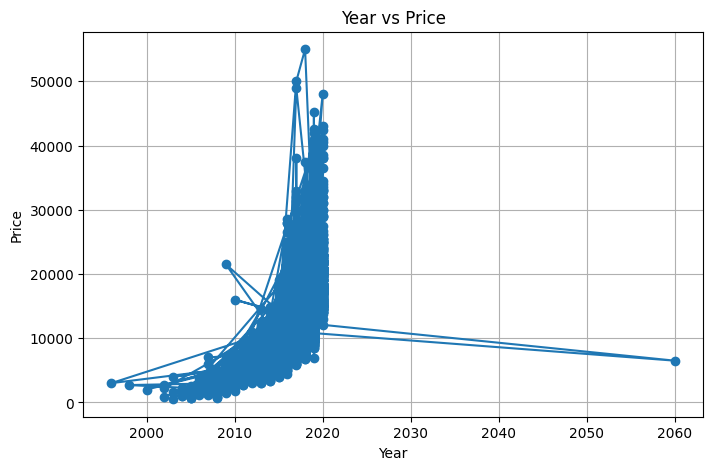

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['year'], df['price'], marker='o')
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)
plt.show()

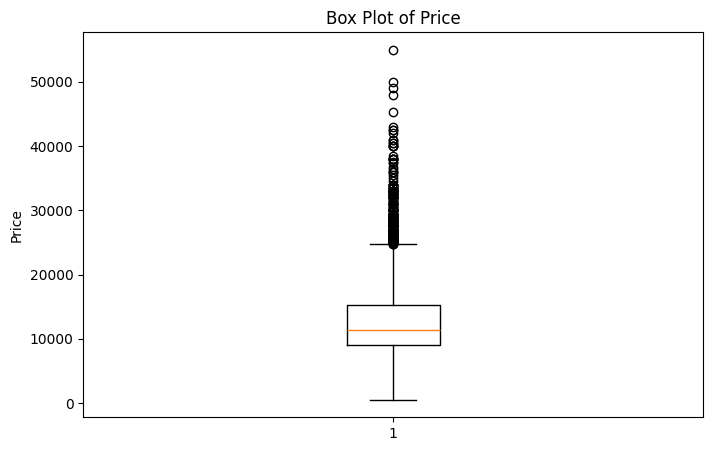

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df['price'])
plt.title("Box Plot of Price")
plt.ylabel("Price")
plt.show()

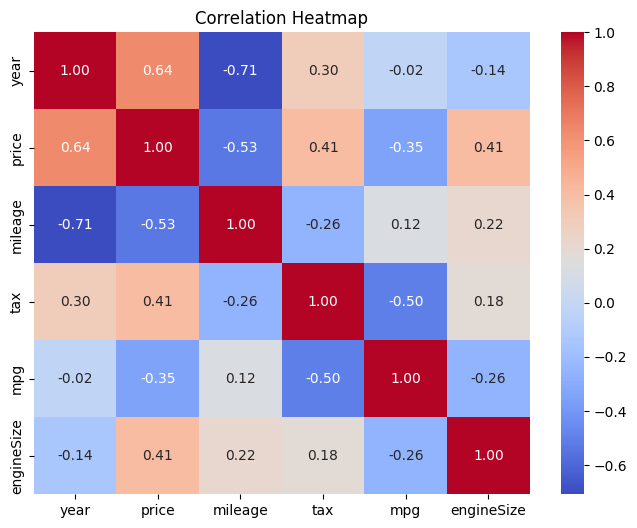

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

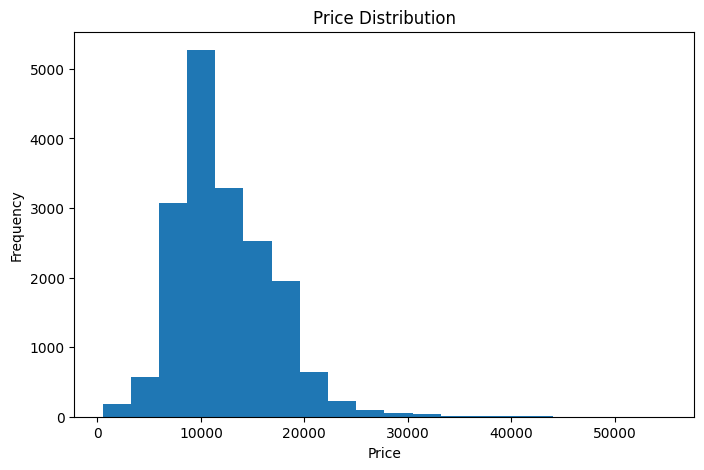

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

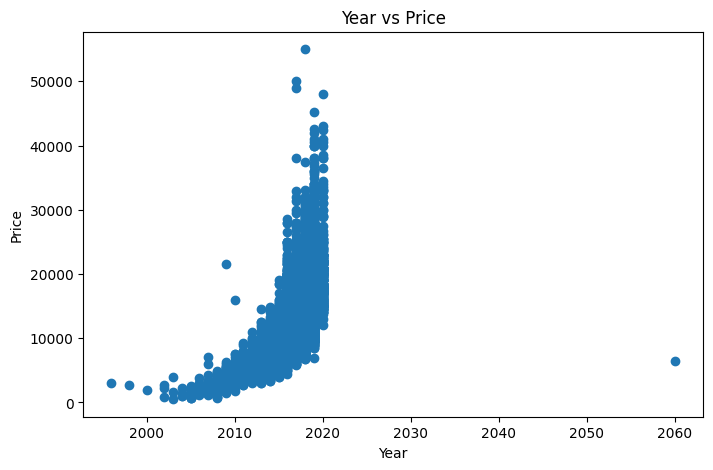

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['price'])
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

In [14]:
df = pd.get_dummies(df)

X = df.drop("price", axis=1)
y = df["price"]

encoded_columns = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

joblib.dump(model, "LR_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoded_columns, "columns.pkl")

print("Model files created successfully")

Model files created successfully


In [28]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as npnp

Model = joblib.load("LR model.pkl")
Scaler = joblib.load("scaler.pkl")
Model_columns = joblib.load("columns.pkl")

St.title("Car Price Prediction App")

Model_name = st.selectbox("Model",["Fiesta","Focus","EcoSport","Kuga","Mondeo"])
Year = st.number_input("Year",2000,2025,2020)
Mileage = st.number_input("Mileage",0,200000,50000)
Tax = st.number_input("Tax",0,500,150)
Mpg = st.number_input("MPG",10.0,100.0,50.0)
engineSize = st.number_input("Engine Size",1.0,5.0,1.5)
transmission = st.selectbox("Transmission",["Manual","Automatic","Semi-Auto"])
fuelType = st.selectbox("Fuel Type",["Petrol","Diesel","Hybrid","Electric"])

if st.button("Predict Price"):
    input_data = pd.DataFrame([{
        "model":model_name,
        "year":year,
        "mileage":mileage,
        "tax":tax,
        "mpg":mpg,
        "engineSize":engineSize,
        "transmission":transmission,
        "fuelType":fuelType
    }])

    Input_encoded = pd.get_dummies(input_data)
    Input_encoded = input_encoded.reindex(columns=model_columns,fill_value=0)
    Input_scaled = scaler.transform(input_encoded)
    Prediction = model.predict(input_scaled)

    St.success(f"Predicted Price: £ {prediction[0]:.2f}")

Writing app.py


In [ ]:
!pip freeze > requirements.txt